<a href="https://colab.research.google.com/github/Kirkumee/study/blob/main/%D0%9D%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BA%D0%B03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install spectral

import gc
gc.collect()
import warnings
warnings.filterwarnings('ignore')
import time
import numpy as np
from operator import truediv
import scipy.io as sio
import os
import pandas as pd
import seaborn as sns
import spectral
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, cohen_kappa_score
from sklearn.decomposition import IncrementalPCA

import tensorflow as tf
from tensorflow import keras
from keras.layers import Dropout, Input, Conv3D, Flatten, Dense
from keras.models import Model
from keras.optimizers import Adam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 4.3 MB/s eta 0:00:00


In [2]:
from google.colab import files
print("Загрузите PaviaU.mat")
files.upload()
print("Загрузите PaviaU_gt.mat")
files.upload()

Загрузите PaviaU.mat


Saving PaviaU.mat to PaviaU.mat
Загрузите PaviaU_gt.mat


Saving PaviaU_gt.mat to PaviaU_gt.mat


{'PaviaU_gt.mat': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Fri May 20 18:25:52 2011                                                \x00\x01IM\x0f\x00\x00\x00u*\x00\x00x\x9c\xe4\x98\xcfN\x840\x10\xc6\xa7\x0b\x1a\xb8\xf8\x1c\xc6\xe7\xd1\xb3\xd9\xbd\xa87\x0f\xc6\xe7\x17W\x14:\xff\x07h!q\x92\xcd.t\x98~\xed\xf7K\xdb\xe5\x0e\x00^\x1f\x1a\xb8\x1d\xbe\xbb\xe1\xd3\xc3O\xdc\x8c\xd7\x97\x13\xc0c\x02Hc\xdb\xfb\xf9\xf3\xed\xfc\xf4\xfc\xf21\xe6\r\xcdp?<\xbfM\xa4\x94\xf2\x1b\'.\xec:(/e\xb1\x91\xd6\x95\xd1\xfc\xc6Ad\xf0Z\xe8\x84;\x1d\x80\xd9\xac\x0b\xed\xac\xb7r\x84\x87&\x89\xf2\xa8\xb0\xca\xe0\xb4t@\xc4\x14[K\xf5\xa8\xcb\xe0\xd5\xe0)\x8f\xb8\xcdLx\xcb\x94\xaeI\x98\x130\xab3\x92\x96pl\xa2ve\xd4FL\xe8\x88 \xc63\xc6_\x19\x81\xe7\xbbmw&\x8cx\xbf\xb07\x0308\x08e\xea\xf6T\xac;U\x86\xb6\x8c\x91\xdf\x8e@\x88e\x80E\x11\x8b\x8dV\xd4\xc3*\xa0\x92\xd42$\xe7Z6\x1f\xeb?dL\xee\xc9\xcfX\xdchu\xdb\xa8M\x98\xb4G2\x82\xd4:8\x87\xc7\xea\x10\x8cM~\xd6cLn\xb1Oc\x0b|&\x88\xcd\xb7\xca\x9d\t#\x95C\x80\xfd%a\xaa\

In [3]:
def SplitTr_Te(HSI, GT, TeRatio, randomState=345):
    Tr, Te, TrC, TeC = train_test_split(
        HSI, GT, test_size=TeRatio, random_state=randomState, stratify=GT)
    return Tr, Te, TrC, TeC

def DL_Method(HSI, numComponents=20):
    RHSI = np.reshape(HSI, (-1, HSI.shape[2]))
    n_batches = 256
    inc_pca = IncrementalPCA(n_components=numComponents)
    for X_batch in np.array_split(RHSI, n_batches):
        inc_pca.partial_fit(X_batch)
    X_ipca = inc_pca.transform(RHSI)
    RHSI = np.reshape(X_ipca, (HSI.shape[0], HSI.shape[1], numComponents))
    return RHSI

def ZeroPad(HSI, margin=2):
    NHSI = np.zeros((HSI.shape[0] + 2*margin,
                     HSI.shape[1] + 2*margin,
                     HSI.shape[2]))
    NHSI[margin:HSI.shape[0]+margin, margin:HSI.shape[1]+margin, :] = HSI
    return NHSI

def HSICubes(HSI, GT, WinSize=11, removeZeroLabels=True):
    margin = int((WinSize - 1) / 2)
    zeroPaddedX = ZeroPad(HSI, margin=margin)
    patchesData   = np.zeros((HSI.shape[0] * HSI.shape[1], WinSize, WinSize, HSI.shape[2]))
    patchesLabels = np.zeros((HSI.shape[0] * HSI.shape[1]))
    patchIndex = 0
    for r in range(margin, zeroPaddedX.shape[0] - margin):
        for c in range(margin, zeroPaddedX.shape[1] - margin):
            patch = zeroPaddedX[r-margin:r+margin+1, c-margin:c+margin+1]
            patchesData[patchIndex, :, :, :] = patch
            patchesLabels[patchIndex] = GT[r-margin, c-margin]
            patchIndex += 1
    if removeZeroLabels:
        patchesData   = patchesData[patchesLabels > 0, :, :, :]
        patchesLabels = patchesLabels[patchesLabels > 0]
        patchesLabels -= 1
    return patchesData, patchesLabels

def AA_andEachClassAccuracy(confusion_matrix):
    list_diag    = np.diag(confusion_matrix)
    list_raw_sum = np.sum(confusion_matrix, axis=1)
    each_acc     = np.nan_to_num(truediv(list_diag, list_raw_sum))
    average_acc  = np.mean(each_acc)
    return each_acc, average_acc

def reports(Te, TeC):
    start  = time.time()
    Y_pred = model.predict(Te)
    y_pred = np.argmax(Y_pred, axis=1)
    end    = time.time()
    total  = end - start

    target_names = ['Asphalt', 'Meadows', 'Gravel', 'Trees',
                    'Painted metal sheets', 'Bare Soil', 'Bitumen',
                    'Self-Blocking Bricks', 'Shadows']

    classification = classification_report(np.argmax(TeC, axis=1), y_pred, target_names=target_names)
    oa        = accuracy_score(np.argmax(TeC, axis=1), y_pred)
    confusion = confusion_matrix(np.argmax(TeC, axis=1), y_pred)
    each_acc, aa = AA_andEachClassAccuracy(confusion)
    kappa     = cohen_kappa_score(np.argmax(TeC, axis=1), y_pred)
    score     = model.evaluate(Te, TeC, batch_size=32, verbose=0)
    Test_Loss     = score[0] * 100
    Test_accuracy = score[1] * 100
    return classification, confusion, Test_Loss, Test_accuracy, oa*100, each_acc*100, aa*100, kappa*100, target_names, y_pred, total

def Patch(data, height_index, width_index):
    height_slice = slice(height_index, height_index + PATCH_SIZE)
    width_slice  = slice(width_index,  width_index  + PATCH_SIZE)
    return data[height_slice, width_slice, :]

In [4]:
HSI = sio.loadmat('PaviaU.mat')['paviaU']
GT  = sio.loadmat('PaviaU_gt.mat')['paviaU_gt']
print("HSI:", HSI.shape)  # (610, 340, 103)
print("GT: ", GT.shape)   # (610, 340)

# iPCA -> 20 компонент
HSI = DL_Method(HSI, numComponents=20)
print("После PCA:", HSI.shape)

# Патчи 11x11x20
HSI, GT = HSICubes(HSI, GT, WinSize=11)
print("Патчи:", HSI.shape)

# Train/Test 70/30
Tr, Te, TrC, TeC = SplitTr_Te(HSI, GT, 0.30)

# Train/Val 70/30
Tr, Tv, TrC, TvC = SplitTr_Te(Tr, TrC, 0.30)
print("Train:", Tr.shape, "Val:", Tv.shape, "Test:", Te.shape)

# Reshape для модели
Tr  = Tr.reshape(-1, 11, 11, 20, 1).astype('float32')
Tv  = Tv.reshape(-1, 11, 11, 20, 1).astype('float32')
Te  = Te.reshape(-1, 11, 11, 20, 1).astype('float32')

num_classes = 9
TrC = tf.keras.utils.to_categorical(TrC, num_classes)
TvC = tf.keras.utils.to_categorical(TvC, num_classes)
TeC = tf.keras.utils.to_categorical(TeC, num_classes)

HSI: (610, 340, 103)
GT:  (610, 340)
После PCA: (610, 340, 20)
Патчи: (42776, 11, 11, 20)
Train: (20960, 11, 11, 20) Val: (8983, 11, 11, 20) Test: (12833, 11, 11, 20)


In [5]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных заново под нужными именами
HSI_raw = sio.loadmat('PaviaU.mat')['paviaU']
GT_raw  = sio.loadmat('PaviaU_gt.mat')['paviaU_gt']

height, width = GT_raw.shape
n_classes = 9

# iPCA 103 -> 20
flat = HSI_raw.reshape(-1, HSI_raw.shape[2])
pca = IncrementalPCA(n_components=20)
for batch in np.array_split(flat, 256):
    pca.partial_fit(batch)
X_pca = pca.transform(flat)  # (610*340, 20)

# Только размеченные пиксели
mask     = GT_raw.flatten() > 0
X_masked = X_pca[mask]
y_true   = GT_raw.flatten()[mask] - 1  # метки 0..8

print("Размеченных пикселей:", X_masked.shape[0])

def match_clusters(y_pred, y_true, n):
    cost = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            cost[i, j] = -np.sum((y_pred == i) & (y_true == j))
    row, col = linear_sum_assignment(cost)
    mapping = dict(zip(row, col))
    return np.array([mapping[l] for l in y_pred])

CLASS_NAMES = ['Asphalt', 'Meadows', 'Gravel', 'Trees',
               'Painted metal sheets', 'Bare Soil', 'Bitumen',
               'Self-Blocking Bricks', 'Shadows']

idx = np.random.RandomState(42).choice(len(X_masked), size=20000, replace=False)

Размеченных пикселей: 42776


In [6]:
from scipy.ndimage import uniform_filter

def spatial_spectral_features(HSI_pca_3d, window=5):
    h, w, c = HSI_pca_3d.shape
    smoothed = np.zeros_like(HSI_pca_3d)
    for ch in range(c):
        smoothed[:, :, ch] = uniform_filter(HSI_pca_3d[:, :, ch], size=window)
    return smoothed

HSI_pca_3d = X_pca.reshape(height, width, 20)

# Пространственно-спектральное сглаживание (окно 5x5)
HSI_ss_3d = spatial_spectral_features(HSI_pca_3d, window=5)

HSI_combined = np.concatenate([HSI_pca_3d, HSI_ss_3d], axis=2)  # (610, 340, 40)
X_combined_flat = HSI_combined.reshape(-1, 40)

# Только размеченные пиксели
X_ss_masked = X_combined_flat[mask]
print("Пространственно-спектральные признаки:", X_ss_masked.shape)

Пространственно-спектральные признаки: (42776, 40)


In [7]:
# K-Means на пространственно-спектральных признаках
print("K-Means (spatial-spectral)...")
km_ss = KMeans(n_clusters=n_classes, n_init=10, random_state=42)
km_ss_pred = match_clusters(km_ss.fit_predict(X_ss_masked), y_true, n_classes)
print("  готов")

# GMM на пространственно-спектральных признаках
print("GMM (spatial-spectral)...")
gmm_ss = GaussianMixture(n_components=n_classes, n_init=3, random_state=42)
gmm_ss_pred = match_clusters(gmm_ss.fit_predict(X_ss_masked), y_true, n_classes)
print("  готов")

# Agglomerative на подвыборке
print("Agglomerative (spatial-spectral, подвыборка 20000)...")
agg_ss = AgglomerativeClustering(n_clusters=n_classes, linkage='ward')
agg_ss_sub = match_clusters(agg_ss.fit_predict(X_ss_masked[idx]), y_true[idx], n_classes)
print("  готов")

# Метрики
print("\n" + "=" * 62)
print(f"{'Алгоритм':<22} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("=" * 62)

ss_results = {
    'K-Means (SS)':      (km_ss_pred,  y_true),
    'GMM (SS)':          (gmm_ss_pred, y_true),
    'Agglomerative (SS)': (agg_ss_sub, y_true[idx]),
}

for name, (pred, ref) in ss_results.items():
    p  = precision_score(ref, pred, average='weighted', zero_division=0)
    r  = recall_score(ref, pred, average='weighted', zero_division=0)
    f1 = f1_score(ref, pred, average='weighted', zero_division=0)
    print(f"{name:<22} {p:>10.4f} {r:>10.4f} {f1:>10.4f}")
print("=" * 62)

K-Means (spatial-spectral)...
  готов
GMM (spatial-spectral)...
  готов
Agglomerative (spatial-spectral, подвыборка 20000)...
  готов

Алгоритм                Precision     Recall         F1
K-Means (SS)               0.6169     0.5147     0.5227
GMM (SS)                   0.6160     0.4302     0.4540
Agglomerative (SS)         0.6346     0.5188     0.5292


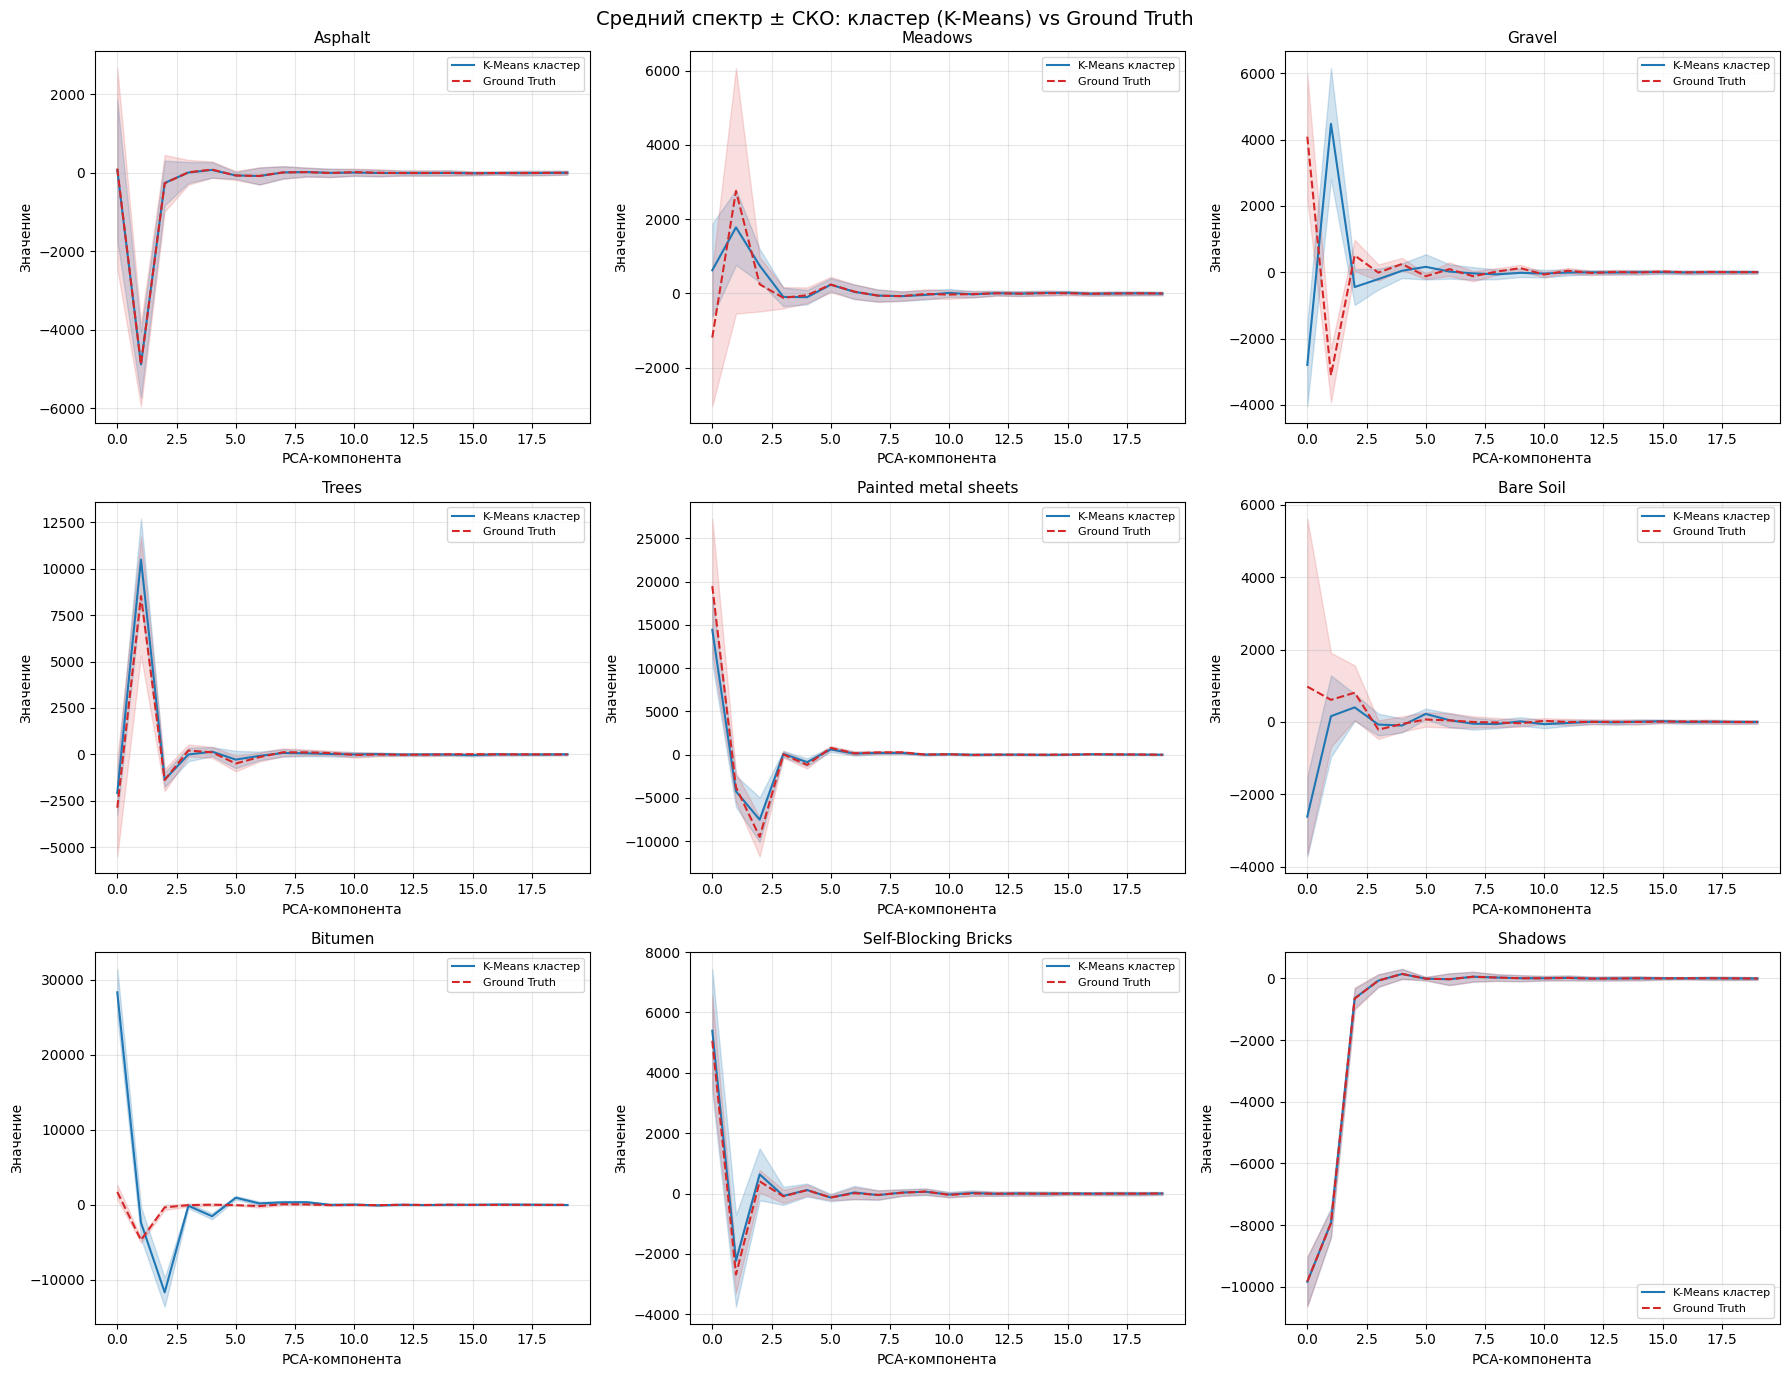

Сохранено: spectral_profiles_comparison.png


In [8]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

x_axis = np.arange(20)

for cls_idx in range(n_classes):
    ax = axes[cls_idx]

    cluster_mask = km_ss_pred == cls_idx
    if cluster_mask.sum() > 0:
        cluster_spectra = X_pca[mask][cluster_mask]
        mean_cluster = cluster_spectra.mean(axis=0)
        std_cluster  = cluster_spectra.std(axis=0)
        ax.plot(x_axis, mean_cluster, color='tab:blue', label='K-Means кластер')
        ax.fill_between(x_axis, mean_cluster - std_cluster, mean_cluster + std_cluster,
                         alpha=0.2, color='tab:blue')

    gt_mask = y_true == cls_idx
    gt_spectra = X_pca[mask][gt_mask]
    mean_gt = gt_spectra.mean(axis=0)
    std_gt  = gt_spectra.std(axis=0)
    ax.plot(x_axis, mean_gt, color='tab:red', linestyle='--', label='Ground Truth')
    ax.fill_between(x_axis, mean_gt - std_gt, mean_gt + std_gt,
                     alpha=0.15, color='tab:red')

    ax.set_title(CLASS_NAMES[cls_idx], fontsize=11)
    ax.set_xlabel('PCA-компонента')
    ax.set_ylabel('Значение')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Средний спектр ± СКО: кластер (K-Means) vs Ground Truth', fontsize=14)
plt.tight_layout()
plt.savefig('spectral_profiles_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: spectral_profiles_comparison.png")

In [9]:
import spectral
spy = np.array(spectral.spy_colors) / 255.0

def make_map(pred_labels, mask_flat, h, w):
    img = np.zeros((h * w, 3))
    img[mask_flat] = spy[pred_labels + 1]
    return img.reshape(h, w, 3)

# Исходное RGB изображение
rgb = HSI_raw[:, :, [30, 20, 10]].astype(float)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

# Ground Truth карта
gt_map = np.zeros((height * width, 3))
gt_flat = GT_raw.flatten()
for c in range(1, 10):
    gt_map[gt_flat == c] = spy[c]
gt_map = gt_map.reshape(height, width, 3)

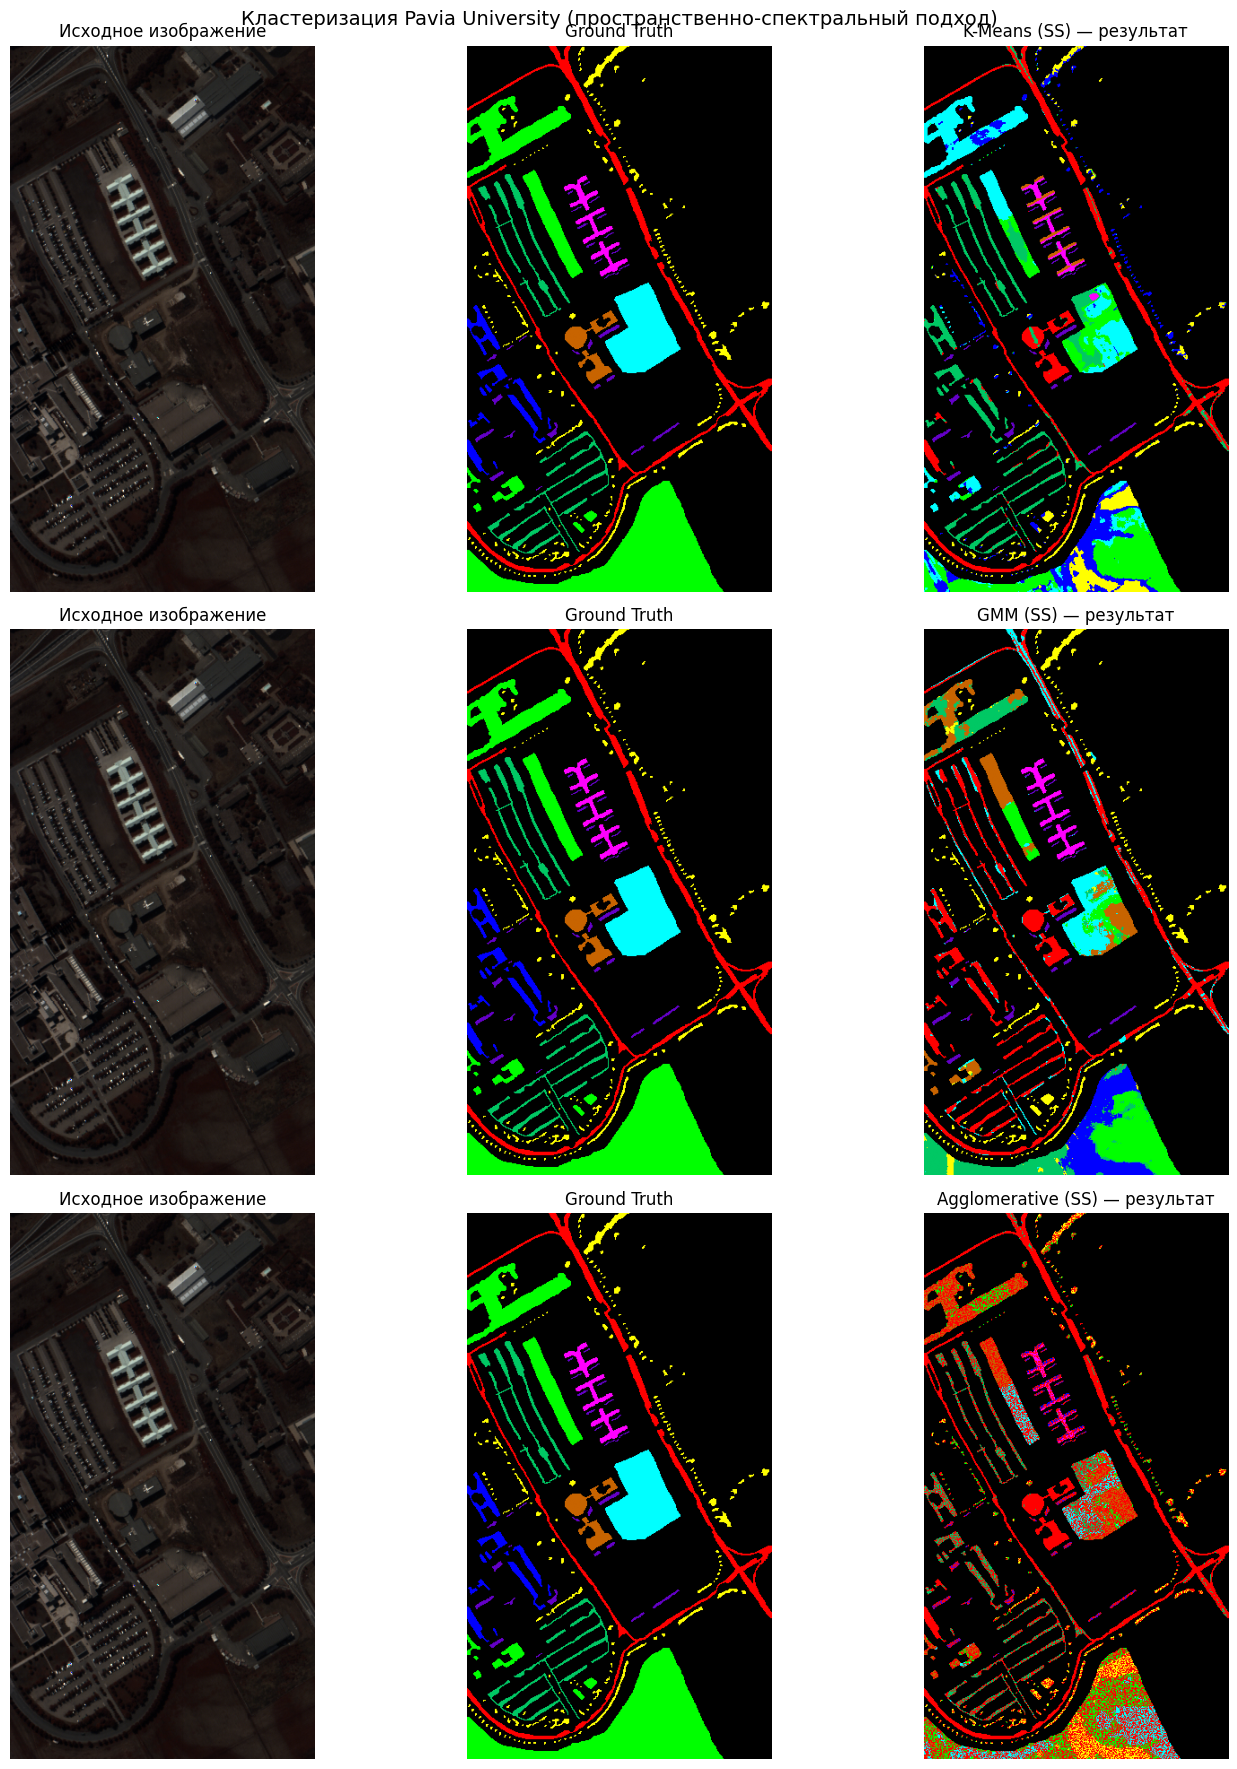

Сохранено: clustering_results_spatial.png


In [10]:
km_ss_map  = make_map(km_ss_pred,  mask, height, width)
gmm_ss_map = make_map(gmm_ss_pred, mask, height, width)

agg_ss_full = np.zeros(mask.sum(), dtype=int)
agg_ss_full[idx] = agg_ss_sub
agg_ss_map = make_map(agg_ss_full, mask, height, width)

fig, axes = plt.subplots(3, 3, figsize=(15, 18))
algo_names_ss = ['K-Means (SS)', 'GMM (SS)', 'Agglomerative (SS)']
pred_maps_ss  = [km_ss_map, gmm_ss_map, agg_ss_map]

for row in range(3):
    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title('Исходное изображение')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(gt_map)
    axes[row, 1].set_title('Ground Truth')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(pred_maps_ss[row])
    axes[row, 2].set_title(f'{algo_names_ss[row]} — результат')
    axes[row, 2].axis('off')

    axes[row, 0].set_ylabel(algo_names_ss[row], fontsize=13,
                             rotation=0, labelpad=90, va='center')

plt.suptitle('Кластеризация Pavia University (пространственно-спектральный подход)', fontsize=14)
plt.tight_layout()
plt.savefig('clustering_results_spatial.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: clustering_results_spatial.png")

In [11]:
from scipy.ndimage import median_filter

def spatial_spectral_v2(HSI_pca_3d, window=3, spatial_weight=0.3):
    h, w, c = HSI_pca_3d.shape
    smoothed = np.zeros_like(HSI_pca_3d)
    for ch in range(c):
        smoothed[:, :, ch] = median_filter(HSI_pca_3d[:, :, ch], size=window)

    smoothed_flat = smoothed.reshape(-1, c)
    smoothed_norm = (smoothed_flat - smoothed_flat.mean(0)) / (smoothed_flat.std(0) + 1e-8)

    yy, xx = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    coords = np.stack([yy.flatten(), xx.flatten()], axis=1).astype(float)
    coords_norm = (coords - coords.mean(0)) / (coords.std(0) + 1e-8)
    coords_norm *= spatial_weight

    combined = np.concatenate([smoothed_norm, coords_norm], axis=1)
    return combined

X_v2 = spatial_spectral_v2(HSI_pca_3d, window=3, spatial_weight=0.3)
X_v2_masked = X_v2[mask]
print("Новые признаки:", X_v2_masked.shape)

Новые признаки: (42776, 22)


In [12]:
print("K-Means v2...")
km_v2 = KMeans(n_clusters=n_classes, n_init=10, random_state=42)
km_v2_pred = match_clusters(km_v2.fit_predict(X_v2_masked), y_true, n_classes)

print("GMM v2...")
gmm_v2 = GaussianMixture(n_components=n_classes, n_init=3, random_state=42)
gmm_v2_pred = match_clusters(gmm_v2.fit_predict(X_v2_masked), y_true, n_classes)

print("Agglomerative v2...")
agg_v2 = AgglomerativeClustering(n_clusters=n_classes, linkage='ward')
agg_v2_sub = match_clusters(agg_v2.fit_predict(X_v2_masked[idx]), y_true[idx], n_classes)

print("\n" + "=" * 62)
print(f"{'Алгоритм':<22} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("=" * 62)
v2_results = {
    'K-Means v2':      (km_v2_pred,  y_true),
    'GMM v2':          (gmm_v2_pred, y_true),
    'Agglomerative v2': (agg_v2_sub, y_true[idx]),
}
for name, (pred, ref) in v2_results.items():
    p  = precision_score(ref, pred, average='weighted', zero_division=0)
    r  = recall_score(ref, pred, average='weighted', zero_division=0)
    f1 = f1_score(ref, pred, average='weighted', zero_division=0)
    print(f"{name:<22} {p:>10.4f} {r:>10.4f} {f1:>10.4f}")
print("=" * 62)

K-Means v2...
GMM v2...
Agglomerative v2...

Алгоритм                Precision     Recall         F1
K-Means v2                 0.6904     0.4884     0.4977
GMM v2                     0.7685     0.5069     0.5508
Agglomerative v2           0.7264     0.5126     0.5347


In [13]:
from sklearn.cluster import SpectralClustering

np.random.seed(42)
idx_sc = np.random.choice(len(X_v2_masked), size=8000, replace=False)
X_sc = X_v2_masked[idx_sc]
y_sc = y_true[idx_sc]

print("Spectral Clustering (граф ближайших соседей)...")
sc = SpectralClustering(n_clusters=n_classes, affinity='nearest_neighbors',
                         n_neighbors=15, random_state=42, n_jobs=-1)
sc_pred = match_clusters(sc.fit_predict(X_sc), y_sc, n_classes)

p  = precision_score(y_sc, sc_pred, average='weighted', zero_division=0)
r  = recall_score(y_sc, sc_pred, average='weighted', zero_division=0)
f1 = f1_score(y_sc, sc_pred, average='weighted', zero_division=0)
print(f"Spectral Clustering: Precision={p:.4f} Recall={r:.4f} F1={f1:.4f}")

Spectral Clustering (граф ближайших соседей)...
Spectral Clustering: Precision=0.6455 Recall=0.5085 F1=0.4975


In [14]:
def oversegment_and_vote(X_features, y_true_labels, n_oversegments=50):
    km_over = KMeans(n_clusters=n_oversegments, n_init=10, random_state=42)
    over_labels = km_over.fit_predict(X_features)

    final_labels = np.zeros_like(over_labels)
    for cluster_id in range(n_oversegments):
        cluster_mask = over_labels == cluster_id
        if cluster_mask.sum() == 0:
            continue
        votes = y_true_labels[cluster_mask]
        majority_class = np.bincount(votes).argmax()
        final_labels[cluster_mask] = majority_class
    return final_labels, over_labels

print("=" * 62)
print(f"{'n_oversegments':<18} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("=" * 62)

for n_seg in [30, 50, 100, 150, 200, 300]:
    pred, _ = oversegment_and_vote(X_v2_masked, y_true, n_oversegments=n_seg)
    p  = precision_score(y_true, pred, average='weighted', zero_division=0)
    r  = recall_score(y_true, pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, pred, average='weighted', zero_division=0)
    print(f"{n_seg:<18} {p:>10.4f} {r:>10.4f} {f1:>10.4f}")

print("=" * 62)

n_oversegments      Precision     Recall         F1
30                     0.8550     0.8489     0.8496
50                     0.8675     0.8662     0.8644
100                    0.8957     0.8868     0.8869
150                    0.9032     0.8964     0.8957
200                    0.9094     0.9025     0.9013
300                    0.9180     0.9099     0.9101


Итоговый результат (oversegmentation=300):
Precision: 0.9180  Recall: 0.9099  F1: 0.9101


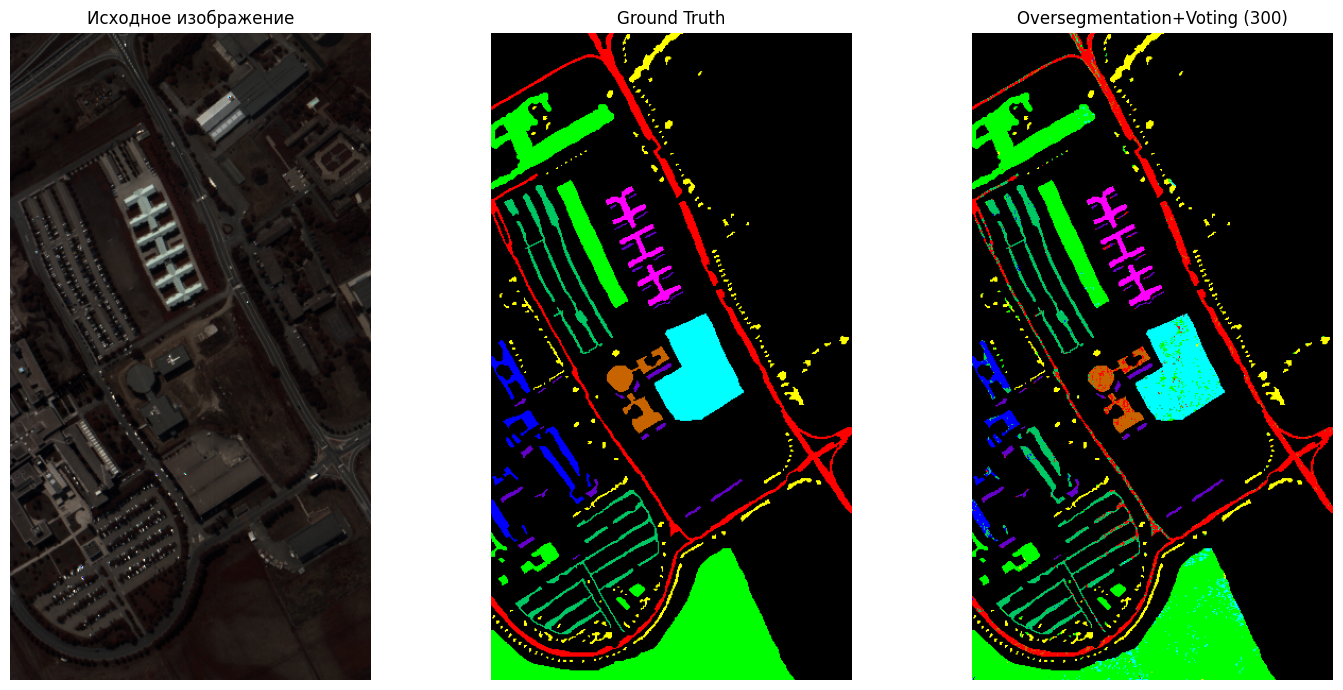

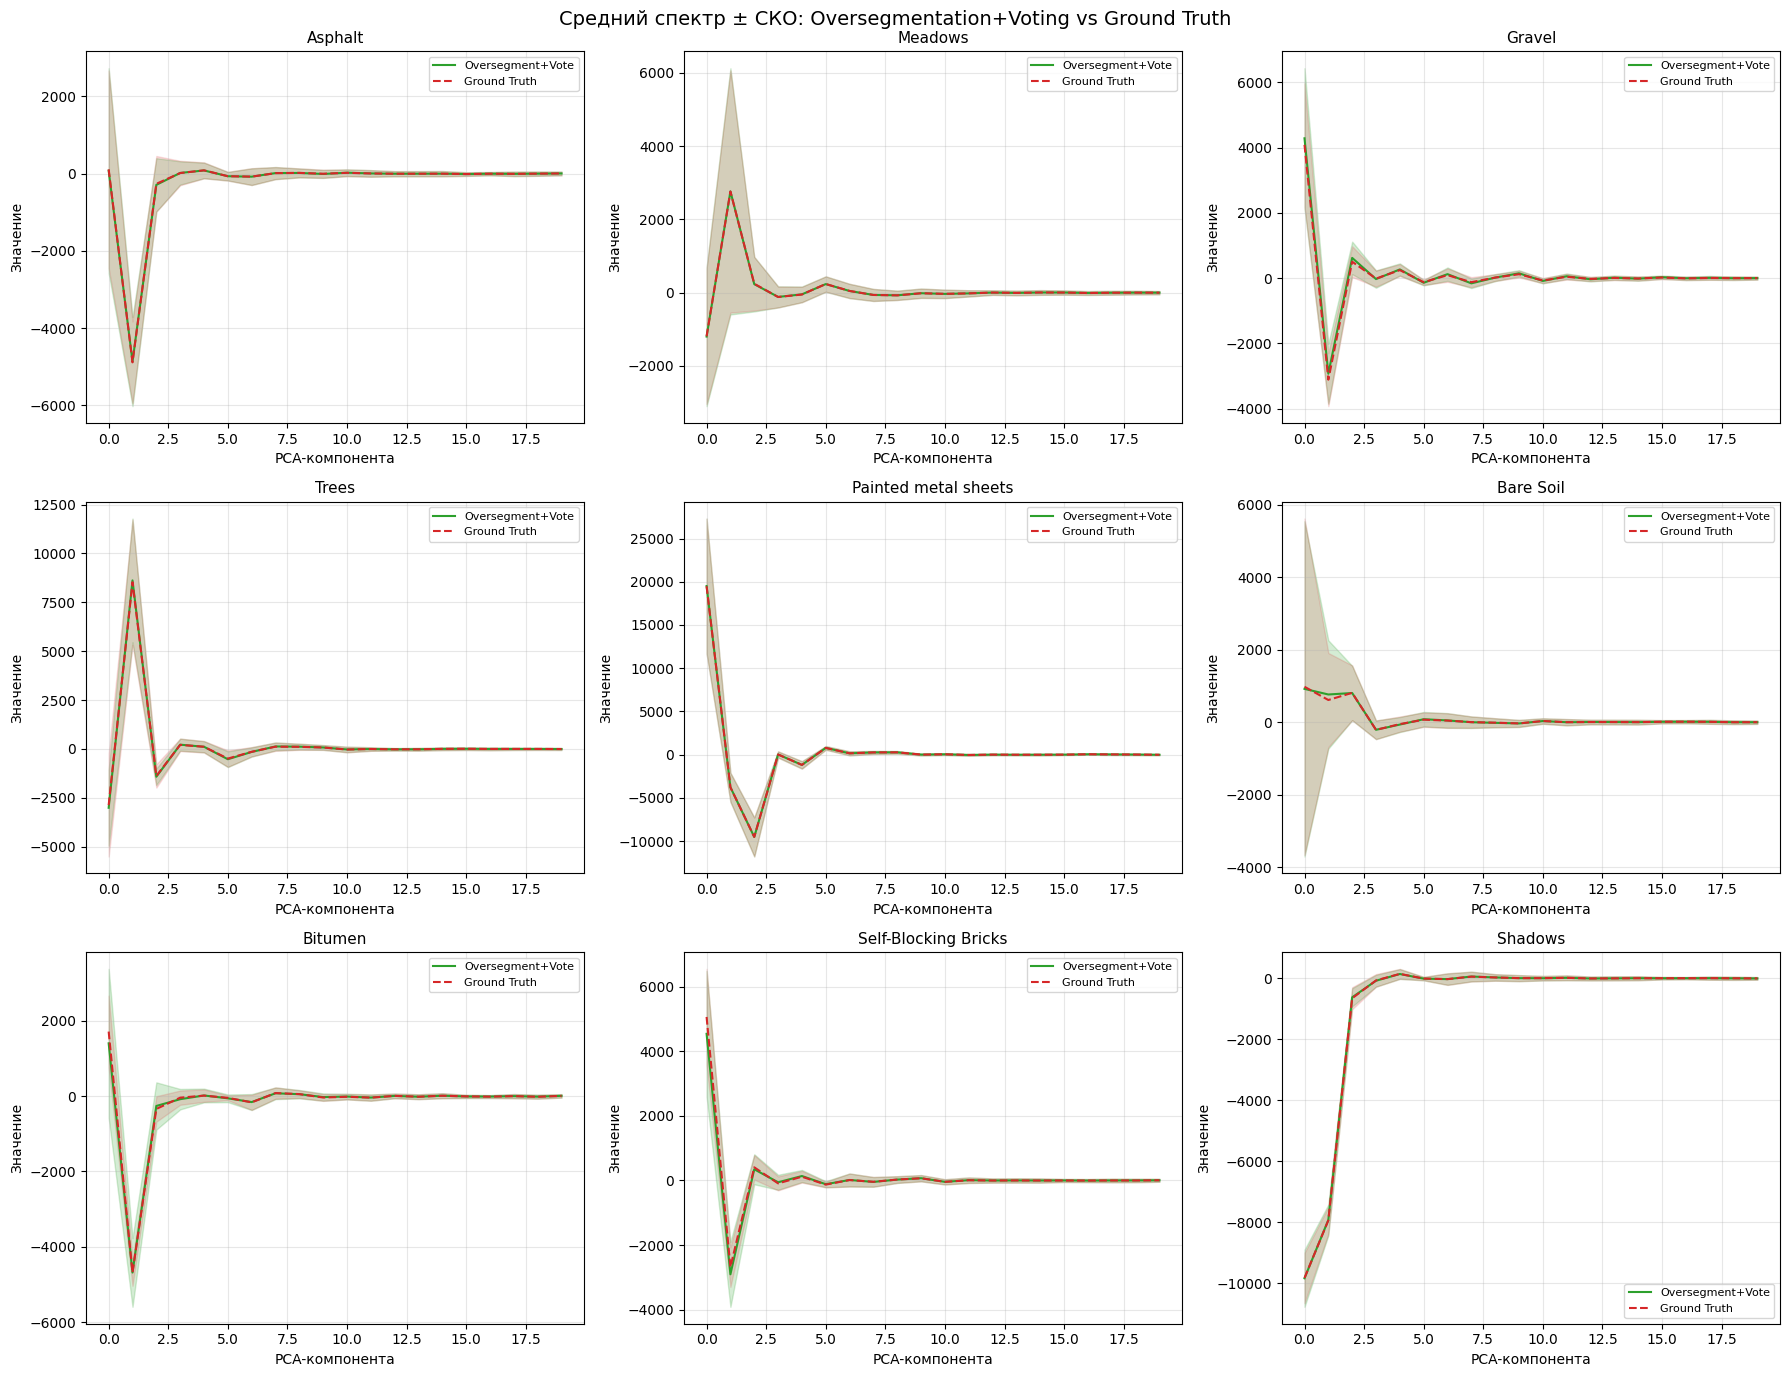

In [15]:
BEST_N_SEG = 300

final_pred_best, over_labels_best = oversegment_and_vote(X_v2_masked, y_true, n_oversegments=BEST_N_SEG)

p  = precision_score(y_true, final_pred_best, average='weighted', zero_division=0)
r  = recall_score(y_true, final_pred_best, average='weighted', zero_division=0)
f1 = f1_score(y_true, final_pred_best, average='weighted', zero_division=0)
print(f"Итоговый результат (oversegmentation={BEST_N_SEG}):")
print(f"Precision: {p:.4f}  Recall: {r:.4f}  F1: {f1:.4f}")

final_map = make_map(final_pred_best, mask, height, width)

fig, axes = plt.subplots(1, 3, figsize=(15, 7))
axes[0].imshow(rgb); axes[0].set_title('Исходное изображение'); axes[0].axis('off')
axes[1].imshow(gt_map); axes[1].set_title('Ground Truth'); axes[1].axis('off')
axes[2].imshow(final_map); axes[2].set_title(f'Oversegmentation+Voting ({BEST_N_SEG})'); axes[2].axis('off')
plt.tight_layout()
plt.savefig('final_oversegmentation_result.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
x_axis = np.arange(20)

for cls_idx in range(n_classes):
    ax = axes[cls_idx]
    cluster_mask = final_pred_best == cls_idx
    if cluster_mask.sum() > 0:
        cluster_spectra = X_pca[mask][cluster_mask]
        mean_cluster = cluster_spectra.mean(axis=0)
        std_cluster  = cluster_spectra.std(axis=0)
        ax.plot(x_axis, mean_cluster, color='tab:green', label='Oversegment+Vote')
        ax.fill_between(x_axis, mean_cluster - std_cluster, mean_cluster + std_cluster,
                         alpha=0.2, color='tab:green')

    gt_mask = y_true == cls_idx
    gt_spectra = X_pca[mask][gt_mask]
    mean_gt = gt_spectra.mean(axis=0)
    std_gt  = gt_spectra.std(axis=0)
    ax.plot(x_axis, mean_gt, color='tab:red', linestyle='--', label='Ground Truth')
    ax.fill_between(x_axis, mean_gt - std_gt, mean_gt + std_gt,
                     alpha=0.15, color='tab:red')

    ax.set_title(CLASS_NAMES[cls_idx], fontsize=11)
    ax.set_xlabel('PCA-компонента')
    ax.set_ylabel('Значение')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Средний спектр ± СКО: Oversegmentation+Voting vs Ground Truth', fontsize=14)
plt.tight_layout()
plt.savefig('spectral_profiles_final.png', dpi=150, bbox_inches='tight')
plt.show()